In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ekf_gt = np.load("../output/ekf_id.npy")
ekf_filt = np.load("../output/ekf_od.npy")
pf_gt = np.load("../output/pf_id.npy")
pf_filt = np.load("../output/pf_od.npy")

In [4]:
ekf_filt.files, ekf_gt.files

(['mean_trajectory', 'covariance_trajectory'],
 ['num_steps',
  'noise_free_motion',
  'real_observations',
  'noise_free_observations',
  'real_robot_path',
  'noise_free_robot_path'])

In [5]:
dt = 0.1
n_steps = ekf_gt['real_robot_path'].shape[0]

def wrap_angle(angle):
    """
    Wraps the given angle to the range [-pi, +pi].

    :param angle: The angle (in rad) to wrap (can be unbounded).
    :return: The wrapped angle (guaranteed to in [-pi, +pi]).
    """

    pi2 = 2 * np.pi

    while angle < -np.pi:
        angle += pi2

    while angle >= np.pi:
        angle -= pi2

    return angle

wrap_angles = np.vectorize(wrap_angle)

def plot_res(gt, filt):
    t = np.arange(0, n_steps * dt, 0.1)
    err = filt['mean_trajectory'] - gt['real_robot_path']
    err[:, 2] = wrap_angles(err[:, 2])
    labels = ["x", "y", "theta"]
    for i in range(3):
        plt.figure()
        plt.plot(t, err[:, i], label=f"error of {labels[i]}", color="b")
        plt.plot(t, 3 * np.sqrt(filt['covariance_trajectory'][i, i,]), label="+3σ", color='r')
        plt.plot(t, -3 * np.sqrt(filt['covariance_trajectory'][i, i,]), label="-3σ", color='r')
        plt.xlabel("Time")
        plt.ylabel("Error")
        plt.title(f"The error of {labels[i]} versus time within ±3σ uncertainty bounds")
        plt.legend()

# Task C

# EKF plots

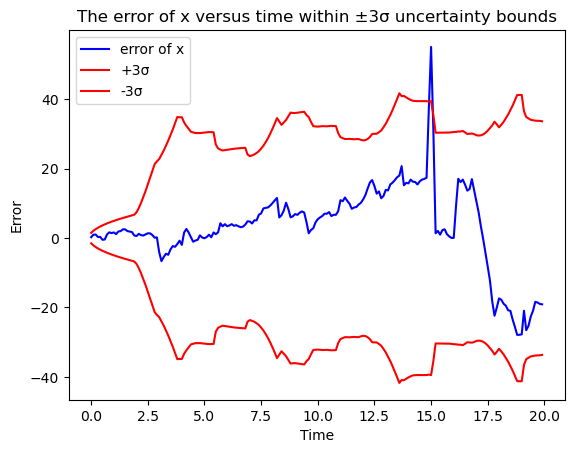

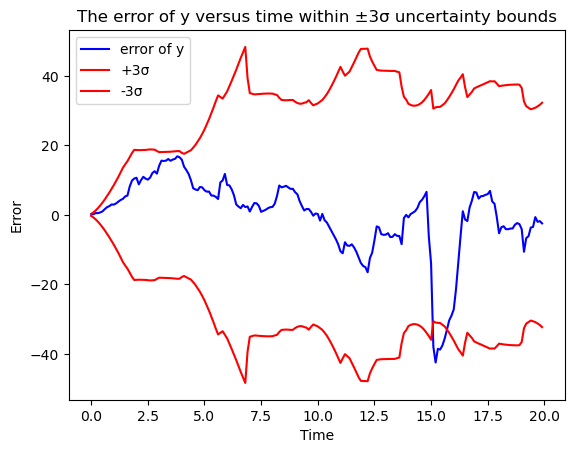

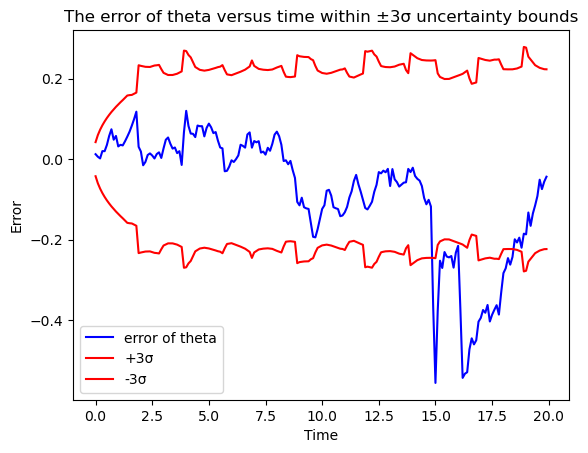

In [6]:
plot_res(ekf_gt, ekf_filt)

# PF plots

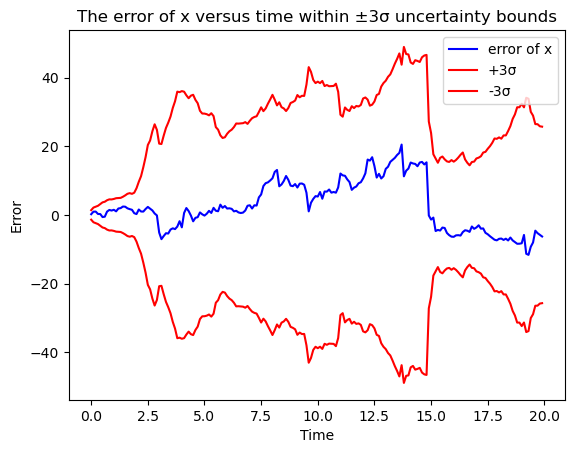

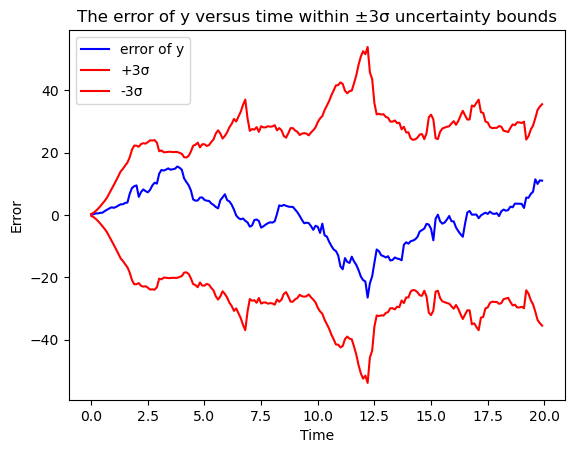

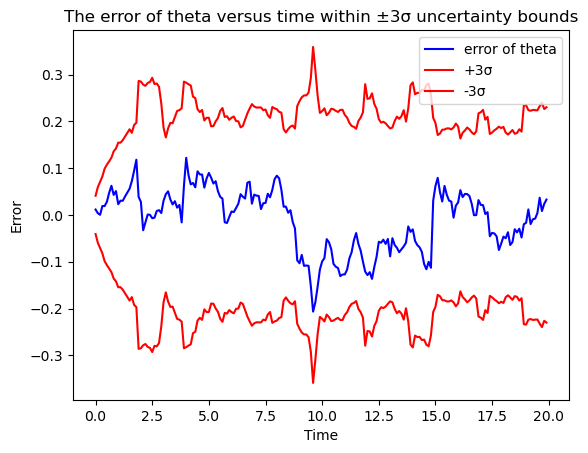

In [7]:
plot_res(pf_gt, pf_filt)

# Task D

## Reduce observation and motion noise

If we reduce the noise in observation (by reducing $Q$) and in motion (by reducing $\alpha$-s) gradually, then we can see that almost the whole state error curve lies within $\pm 3 \sigma$ uncertainty bounds, and the error is much smaller then in task C: 

EKF: about $\pm 0.5$ in $x,\ y$ and about $\pm 0.02$ in $\theta$, it is 10 times less than in task C

PF: about $\pm 1$ in $x,\ y$ and about $\pm 0.004$ in $\theta$, it is 10 times less than in task C.

It means that with less noise the filtered path is more accurate. And the covariance is less, so it means higher confidence in estimates.

The plots below are given with the following parameters:

Extended Kalman Filter: ```python3 run.py  -f 'ekf' --animate -o output -n 200 -s -b 0.0 -a 0.01 0.0006 0.004 0.005```

Particle filter: ```python3 run.py  -f 'pf' --animate -o output -n 200 -s -b 1e-2 -a 0.01 0.0006 0.004 0.005```

### EKF

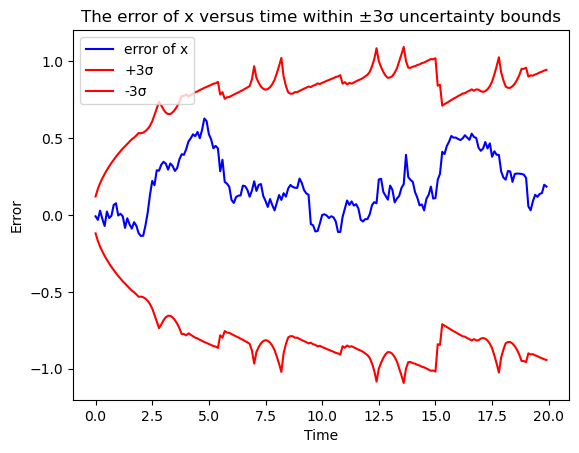

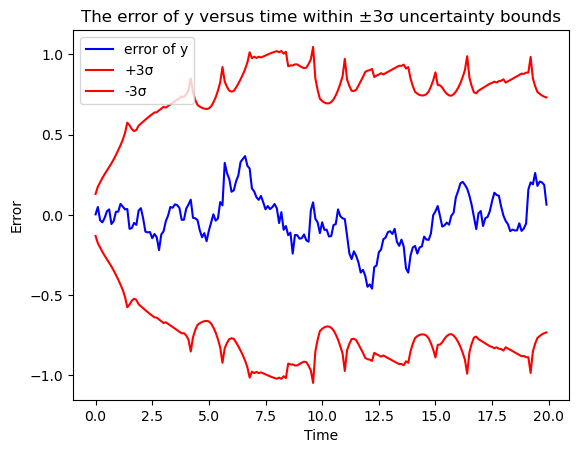

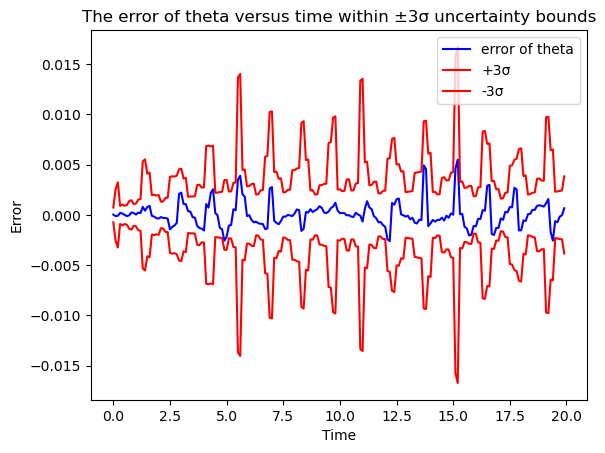

In [8]:
gt = np.load("../output/ekf_id_less_noise.npy")
filt = np.load("../output/ekf_od_less_noise.npy")
plot_res(gt, filt)

### PF

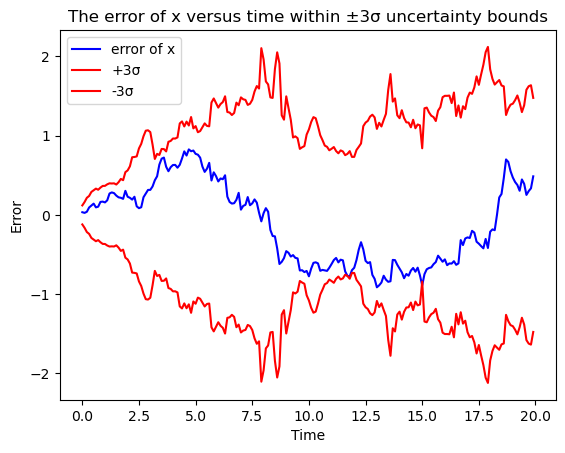

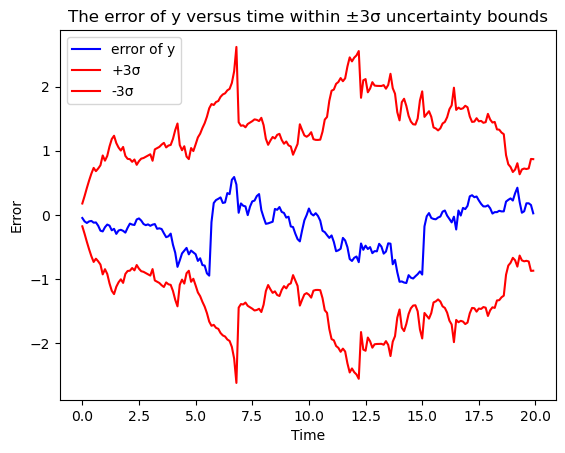

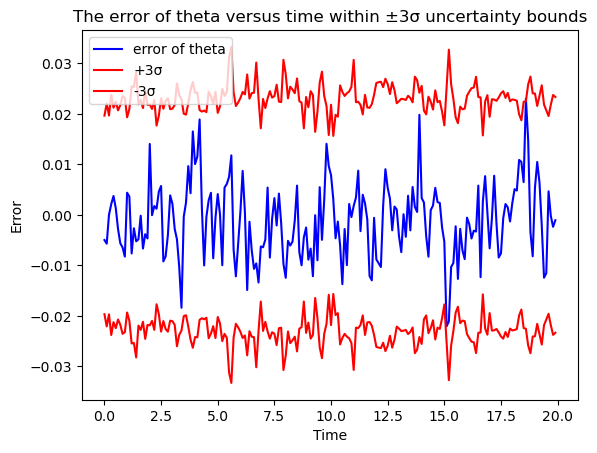

In [9]:
gt = np.load("../output/pf_id_less_noise.npy")
filt = np.load("../output/pf_od_less_noise.npy")
plot_res(gt, filt)

## Reduce number of particles

If we decrease the number of particles, then PF results in bigger error (reaching 20 in $x,\ y$ and $0.2$ in $theta$). Besides, the state error curve goes outside $\pm 3\sigma$ uncertainty bounds approximately more than 99.73% of the time. The plots below are given with the following parameters:

``` python3 run.py  -f 'pf' --animate -o output -n 200 --num-particles 30 -s```

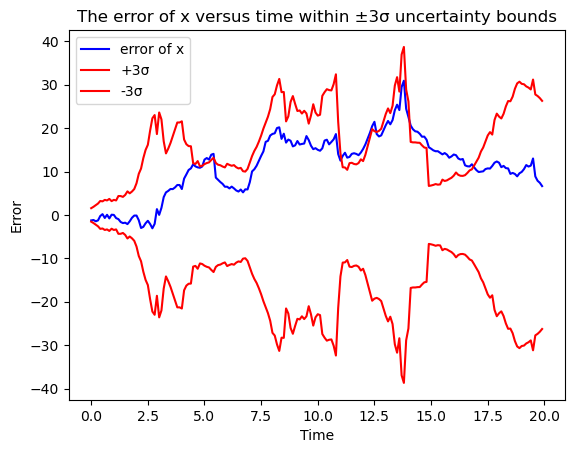

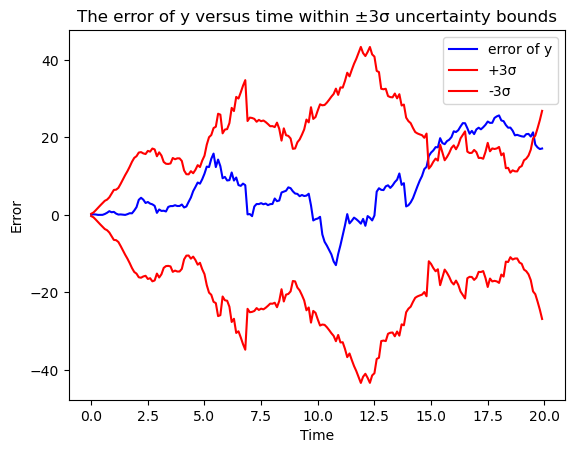

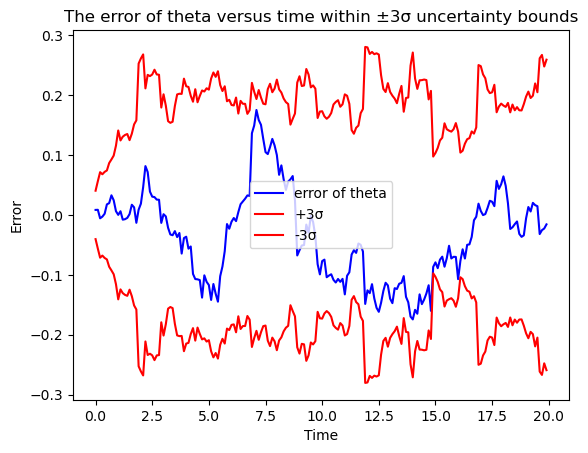

In [10]:
gt = np.load("../output/pf_id_less_part.npy")
filt = np.load("../output/pf_od_less_part.npy")
plot_res(gt, filt)

## Underestimated or overestimated noise parameters

If the noise parameters in the filter are underestimated, it results in higher confidence in the estimates but also introduces greater inaccuracies. This happens because the filter becomes more prone to bias, drifting away from the true state. On the other hand, if the noise parameters are overestimated, the filter shows lower confidence in its estimates but tends to stay closer to the true state. This reduces bias and improves stability. In general, it is better to slightly overestimate noise rather than underestimate it, as this approach typically produces more reliable and less biased estimates of the robot's trajectory.